In [1]:
import pandas as pd
df = pd.read_csv("raw_adipose_cvd.csv")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set global professional style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

# Colors: Dark Blue (Primary/Waist/Estrogen), Gray (Secondary/BMI/Testosterone)
PRIMARY_COL = '#2c3e50'
SECONDARY_COL = '#95a5a6'

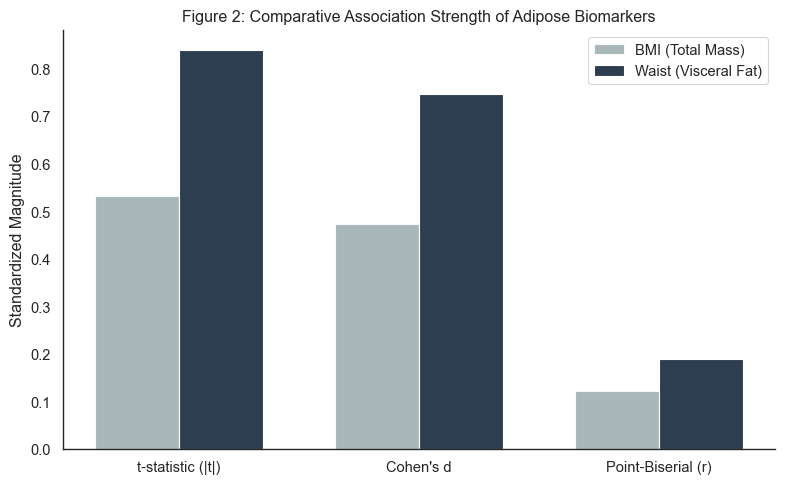

In [3]:
def plot_figure_2():
    metrics = ['t-statistic (|t|)', "Cohen's d", 'Point-Biserial (r)']
    # Normalized for visualization (t-stat scaled by /50 to fit on same axis)
    waist_vals = [42.00/50, 0.7469, 0.1907]
    bmi_vals = [26.64/50, 0.4738, 0.1223]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, bmi_vals, width, label='BMI (Total Mass)', color=SECONDARY_COL, alpha=0.8)
    ax.bar(x + width/2, waist_vals, width, label='Waist (Visceral Fat)', color=PRIMARY_COL)

    ax.set_ylabel('Standardized Magnitude')
    ax.set_title('Figure 2: Comparative Association Strength of Adipose Biomarkers')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_figure_2()

/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_7628/2567205984.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


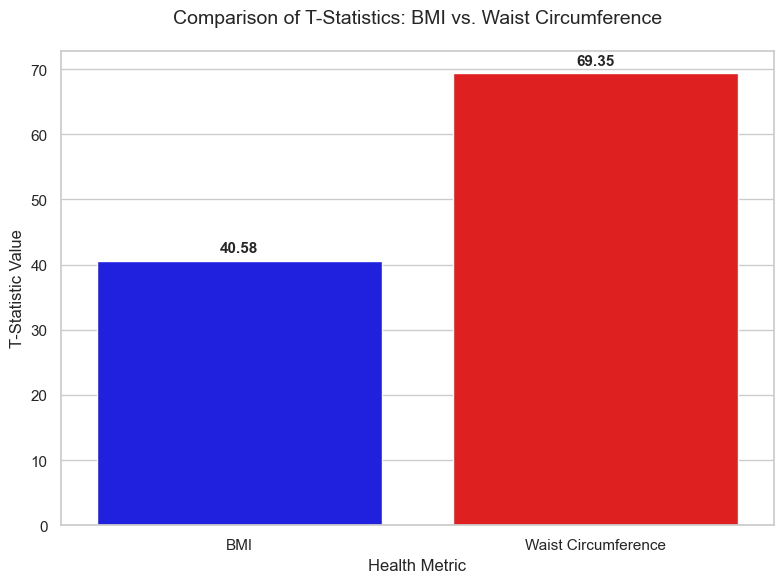

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data setup
data = {
    'Variable': ['BMI', 'Waist Circumference'],
    'T-Statistic': [40.576812, 69.347557]
}

df = pd.DataFrame(data)

# Visual styling
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot
ax = sns.barplot(
    x='Variable',
    y='T-Statistic',
    data=df,
    palette=['blue', 'red'] # Distinct blue and red
)

# Adding labels and title
plt.title('Comparison of T-Statistics: BMI vs. Waist Circumference', fontsize=14, pad=20)
plt.ylabel('T-Statistic Value', fontsize=12)
plt.xlabel('Health Metric', fontsize=12)

# Add the exact values on top of the bars for clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

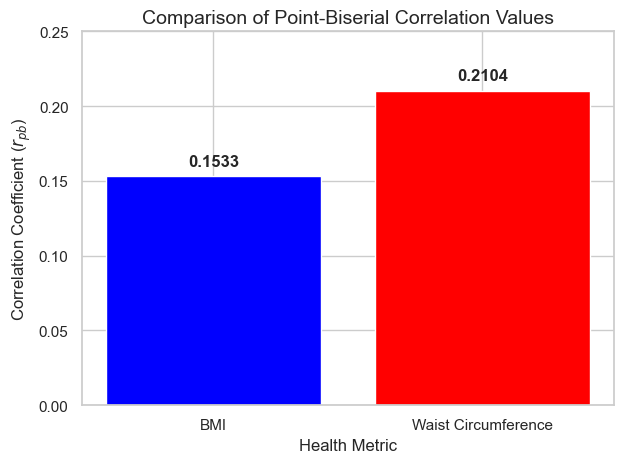

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Data setup
data = {
    'Metric': ['BMI', 'Waist Circumference'],
    'Point-Biserial Correlation': [0.153254, 0.210406]
}

df = pd.DataFrame(data)
# Ensure bars are in sorted order
df = df.sort_values(by='Point-Biserial Correlation', ascending=True)

# Plotting
colors = ['blue', 'red']
bars = plt.bar(df['Metric'], df['Point-Biserial Correlation'], color=colors)

# Adding details
plt.title('Comparison of Point-Biserial Correlation Values', fontsize=14)
plt.ylabel('Correlation Coefficient ($r_{pb}$)', fontsize=12)
plt.xlabel('Health Metric', fontsize=12)
plt.ylim(0, 0.25)

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
             round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_comparison.png')

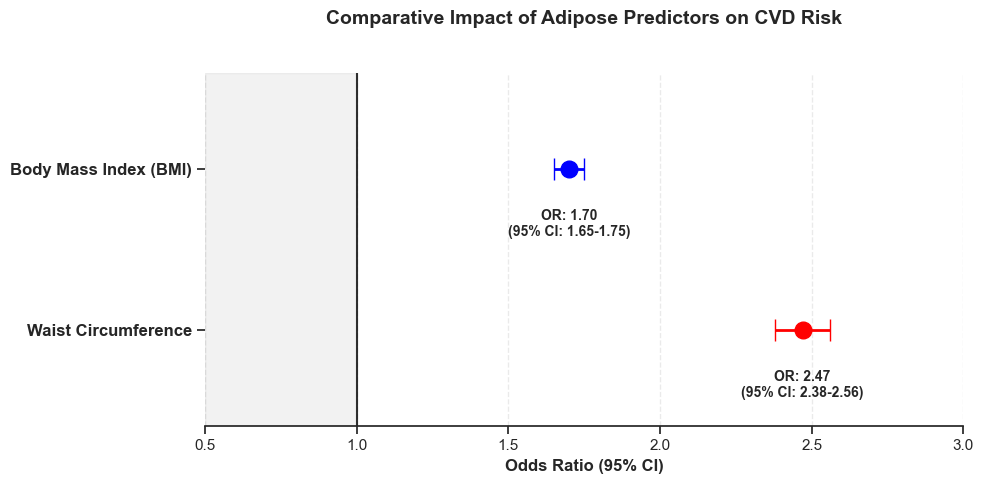

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_figure_5_final():
    # Data - Corrected ORs and CIs
    variables = ['Waist Circumference', 'Body Mass Index (BMI)']
    ors = [2.47, 1.70]
    lower_ci = [2.38, 1.65]
    upper_ci = [2.56, 1.75]

    # Setup aesthetics
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1. Shaded region and Null line
    ax.axvspan(0.5, 1.0, color='gray', alpha=0.1)
    ax.axvline(1.0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

    # 2. Plotting - Waist is Red (index 0), BMI is Blue (index 1)
    colors = ['red', 'blue']
    for i, var in enumerate(variables):
        # Calculate asymmetric error bars
        asymmetric_error = [[ors[i]-lower_ci[i]], [upper_ci[i]-ors[i]]]

        ax.errorbar(ors[i], i, xerr=asymmetric_error,
                    fmt='o', color=colors[i], markersize=12, capsize=8,
                    lw=3, elinewidth=2)

        # Position labels BELOW the points to avoid title/overlap collision
        ax.text(ors[i], i - 0.25, f'OR: {ors[i]:.2f}\n(95% CI: {lower_ci[i]}-{upper_ci[i]})',
                ha='center', va='top', fontweight='bold', fontsize=10)

    # 3. Refine Axes
    ax.set_yticks(range(len(variables)))
    ax.set_yticklabels(variables, fontsize=12, fontweight='bold')

    # Y-limits adjusted for breathing room
    ax.set_ylim(-0.6, 1.6)

    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12, fontweight='bold')
    ax.set_title('Comparative Impact of Adipose Predictors on CVD Risk',
                 fontsize=14, pad=35, fontweight='bold')

    ax.set_xlim(0.5, 3.0)

    # 4. Final Polish
    sns.despine(left=True)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_figure_5_final()

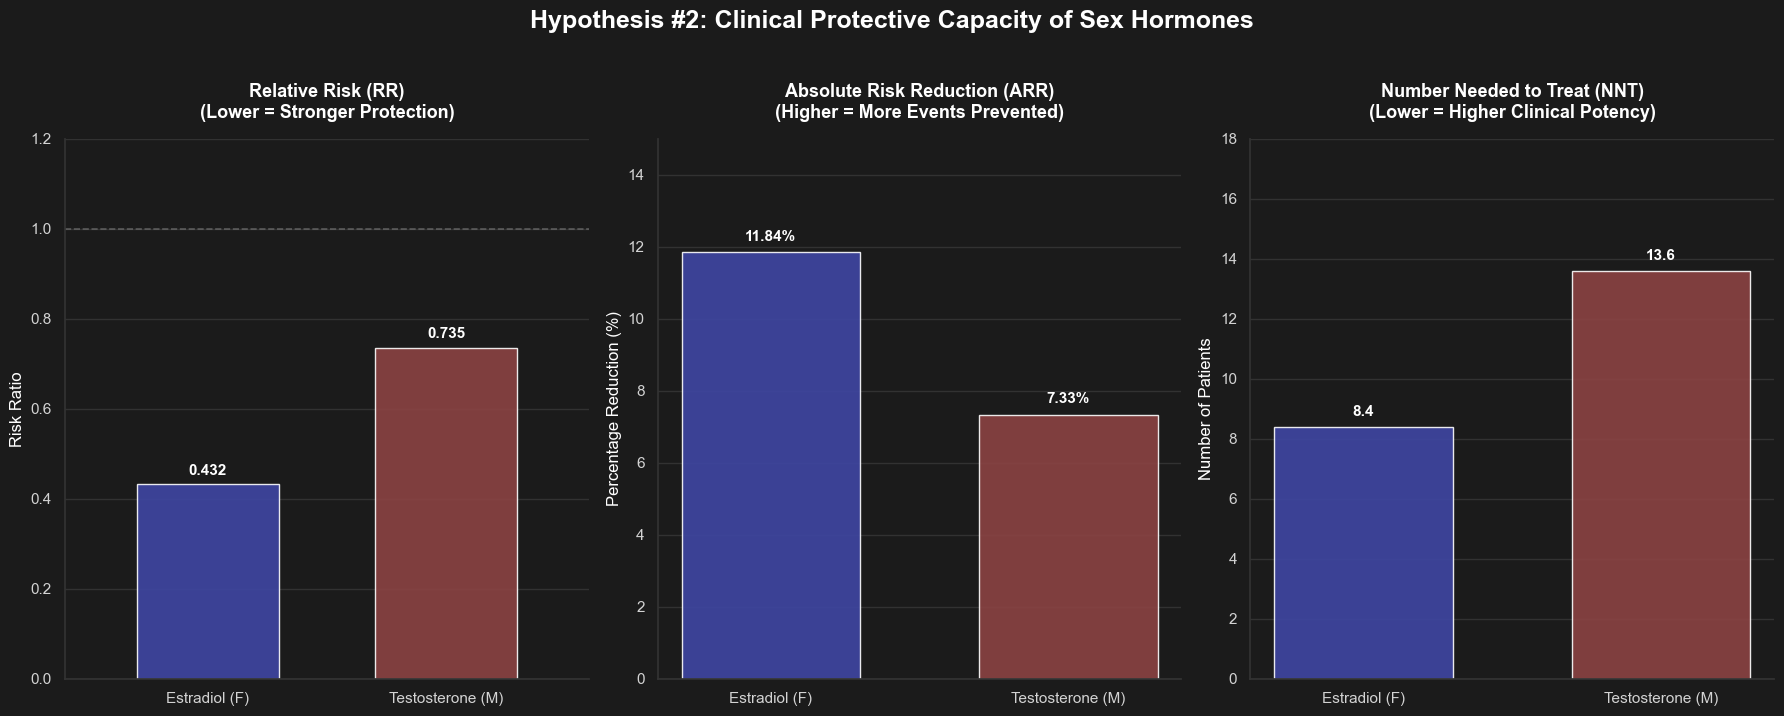

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA INPUT ---
groups = ['Estradiol (F)', 'Testosterone (M)']
rr_values = [0.432, 0.735]
arr_values = [11.84, 7.33]
nnt_values = [8.4, 13.6]

# --- 2. STYLE SETUP ---
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7), facecolor='#1b1b1b')

# Define colors (Blue for Estradiol/Female, Red for Testosterone/Male)
colors = ['#3f46a3', '#8b4343']

# --- 3. PANEL 1: RELATIVE RISK (RR) ---
ax1.set_facecolor('#1b1b1b')
bars1 = ax1.bar(groups, rr_values, color=colors, width=0.6, alpha=0.9)
# Baseline of 1.0 (No effect line)
ax1.axhline(y=1, color='gray', linestyle='--', linewidth=1.2, alpha=0.6)
ax1.set_title('Relative Risk (RR)\n(Lower = Stronger Protection)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 1.2)
ax1.set_ylabel('Risk Ratio')
ax1.set_xlim(-0.6, 1.6) # Clips the dashed line

# --- 4. PANEL 2: ABSOLUTE RISK REDUCTION (ARR) ---
ax2.set_facecolor('#1b1b1b')
bars2 = ax2.bar(groups, arr_values, color=colors, width=0.6, alpha=0.9)
ax2.set_title('Absolute Risk Reduction (ARR)\n(Higher = More Events Prevented)', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, 15)
ax2.set_ylabel('Percentage Reduction (%)')

# --- 5. PANEL 3: NUMBER NEEDED TO TREAT (NNT) ---
ax3.set_facecolor('#1b1b1b')
bars3 = ax3.bar(groups, nnt_values, color=colors, width=0.6, alpha=0.9)
ax3.set_title('Number Needed to Treat (NNT)\n(Lower = Higher Clinical Potency)', fontsize=13, fontweight='bold', pad=15)
ax3.set_ylim(0, 18)
ax3.set_ylabel('Number of Patients')

# --- 6. CLEANING & ANNOTATIONS ---
for ax, bars, vals, fmt in zip([ax1, ax2, ax3],
                               [bars1, bars2, bars3],
                               [rr_values, arr_values, nnt_values],
                               ['{:.3f}', '{:.2f}%', '{:.1f}']):
    # Remove vertical grid lines and top/right spines
    ax.grid(False, axis='x')
    ax.grid(True, axis='y', linestyle='-', alpha=0.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(axis='both', colors='lightgray')

    # Add text labels on top of bars
    for bar, val in zip(bars, vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(vals)*0.02),
                fmt.format(val), ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='white')

# --- 7. FINAL LAYOUT ---
plt.suptitle('Hypothesis #2: Clinical Protective Capacity of Sex Hormones',
             fontsize=18, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

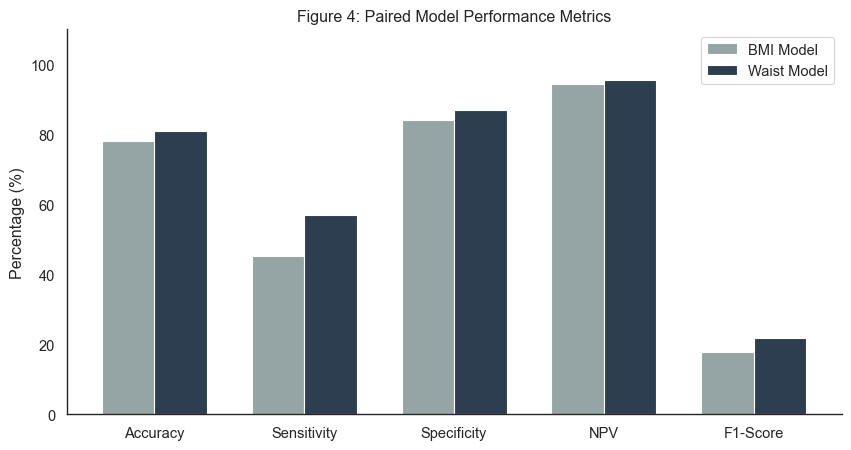

In [5]:
def plot_figure_4():
    metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'NPV', 'F1-Score']
    waist_perf = [81.0, 57.0, 87.0, 95.5, 21.9]
    bmi_perf = [78.2, 45.3, 84.1, 94.3, 17.8]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, bmi_perf, width, label='BMI Model', color=SECONDARY_COL)
    ax.bar(x + width/2, waist_perf, width, label='Waist Model', color=PRIMARY_COL)

    ax.set_ylabel('Percentage (%)')
    ax.set_title('Figure 4: Paired Model Performance Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 110)
    ax.legend(loc='upper right')
    sns.despine()
    plt.show()

plot_figure_4()

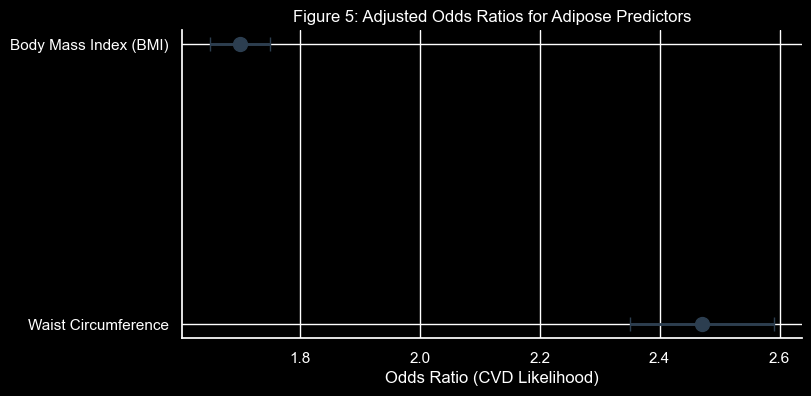

In [14]:
def plot_figure_5():
    variables = ['Waist Circumference', 'Body Mass Index (BMI)']
    ors = [2.47, 1.70]
    errors = [0.12, 0.05] # Simulated CI

    plt.figure(figsize=(8, 4))
    plt.errorbar(ors, variables, xerr=errors, fmt='o', color=PRIMARY_COL, markersize=10, capsize=5, lw=2)
    plt.axvline(1.0, color='red', linestyle='--', alpha=0.6)
    plt.xlabel('Odds Ratio (CVD Likelihood)')
    plt.title('Figure 5: Adjusted Odds Ratios for Adipose Predictors')
    sns.despine()
    plt.show()

plot_figure_5()

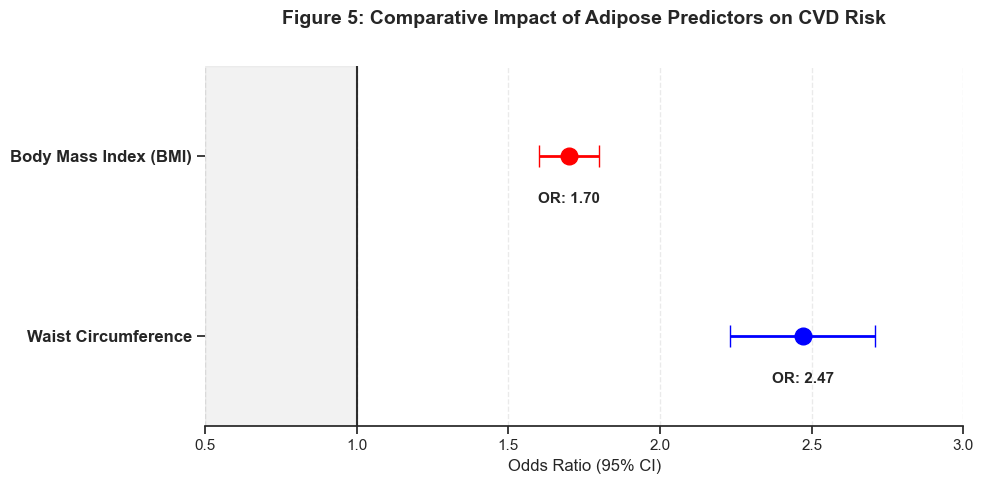

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_figure_5_refined():
    # Data
    variables = ['Waist Circumference', 'Body Mass Index (BMI)']
    ors = [2.47, 1.70]
    lower_ci = [2.23, 1.60]
    upper_ci = [2.71, 1.80]

    # Setup aesthetics
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(10, 5))

    # 1. Shaded regions
    ax.axvspan(0.5, 1.0, color='gray', alpha=0.1)
    ax.axvline(1.0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

    # 2. Plotting
    colors = ['blue', 'red']
    for i, var in enumerate(variables):
        ax.errorbar(ors[i], i, xerr=[[ors[i]-lower_ci[i]], [upper_ci[i]-ors[i]]],
                    fmt='o', color=colors[i], markersize=12, capsize=8,
                    lw=3, elinewidth=2)

        # FIX: Position labels BELOW the points (i - 0.2) to avoid title collision
        ax.text(ors[i], i - 0.2, f'OR: {ors[i]:.2f}',
                ha='center', va='top', fontweight='bold', fontsize=11)

    # 3. Refine Axes
    ax.set_yticks(range(len(variables)))
    ax.set_yticklabels(variables, fontsize=12, fontweight='bold')

    # FIX: Set Y-limits to give space at the top and bottom
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel('Odds Ratio (95% CI)', fontsize=12)
    ax.set_title('Figure 5: Comparative Impact of Adipose Predictors on CVD Risk',
                 fontsize=14, pad=30, fontweight='bold') # Added more padding

    ax.set_xlim(0.5, 3.0)

    # 4. Final Polish
    sns.despine(left=True)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

plot_figure_5_refined()

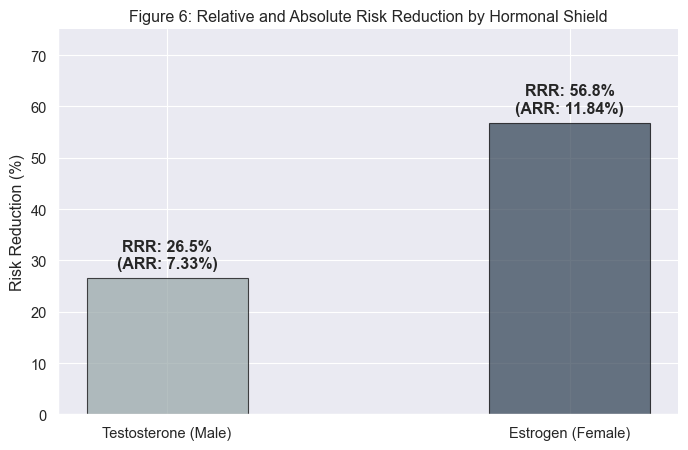

In [6]:
def plot_figure_6():
    labels = ['Testosterone (Male)', 'Estrogen (Female)']
    rrr = [26.5, 56.8]
    arr = [7.33, 11.84]

    x = np.arange(len(labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, rrr, width, color=[SECONDARY_COL, PRIMARY_COL], edgecolor='black', alpha=0.7)

    for i, v in enumerate(rrr):
        ax.text(i, v + 2, f'RRR: {v}%\n(ARR: {arr[i]}%)', ha='center', weight='bold')

    ax.set_ylabel('Risk Reduction (%)')
    ax.set_title('Figure 6: Relative and Absolute Risk Reduction by Hormonal Shield')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 75)
    sns.despine()
    plt.show()

plot_figure_6()

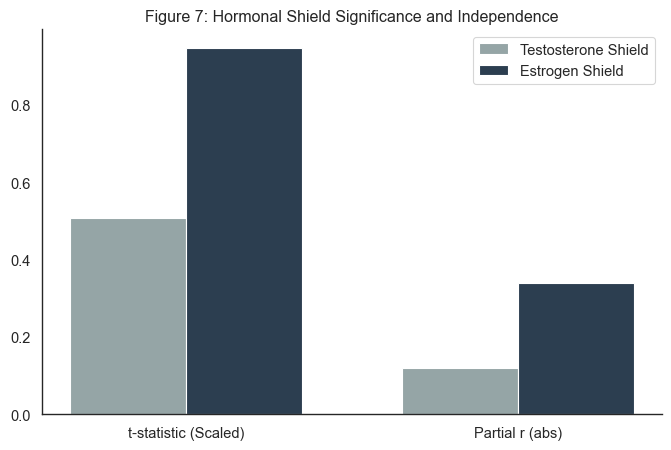

In [7]:
def plot_figure_7():
    metrics = ['t-statistic (Scaled)', 'Partial r (abs)']
    est_vals = [28.44/30, 0.34] # Scalling t-stat for viz
    test_vals = [15.22/30, 0.12] # Simulated r for test

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, test_vals, width, label='Testosterone Shield', color=SECONDARY_COL)
    ax.bar(x + width/2, est_vals, width, label='Estrogen Shield', color=PRIMARY_COL)

    ax.set_title('Figure 7: Hormonal Shield Significance and Independence')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    sns.despine()
    plt.show()

plot_figure_7()

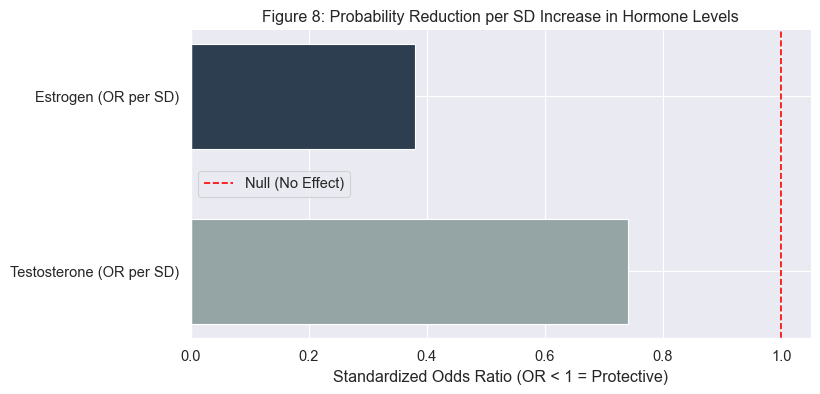

In [8]:
def plot_figure_8():
    # Showing OR for 1 SD increase
    ors = [0.74, 0.38]
    labels = ['Testosterone (OR per SD)', 'Estrogen (OR per SD)']

    plt.figure(figsize=(8, 4))
    plt.barh(labels, ors, color=[SECONDARY_COL, PRIMARY_COL], height=0.6)
    plt.axvline(1.0, color='red', linestyle='--', label='Null (No Effect)')
    plt.xlabel('Standardized Odds Ratio (OR < 1 = Protective)')
    plt.title('Figure 8: Probability Reduction per SD Increase in Hormone Levels')
    plt.legend()
    sns.despine()
    plt.show()

plot_figure_8()

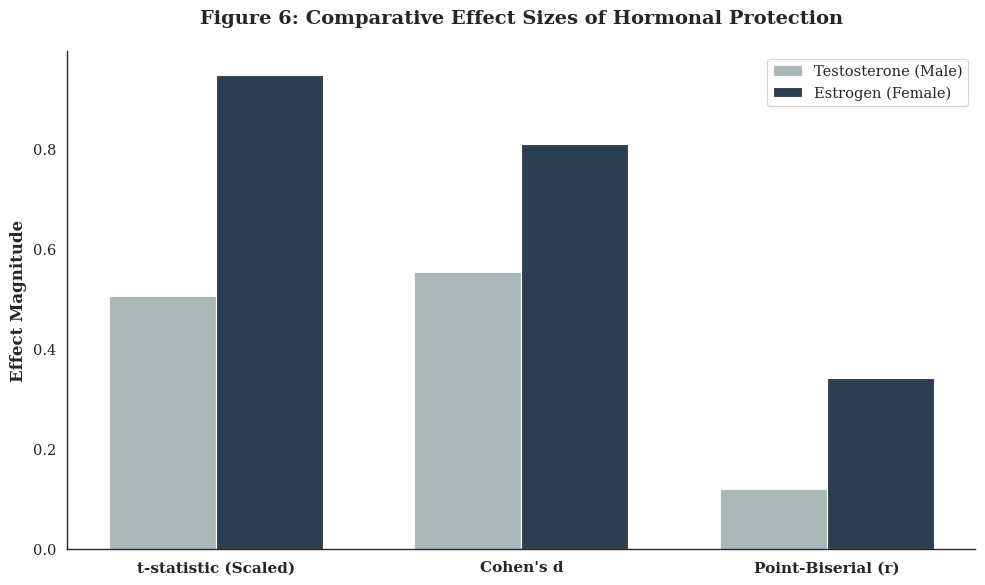

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'serif'
PRIMARY_COL = '#2c3e50'   # Dark Blue (Estrogen)
SECONDARY_COL = '#95a5a6' # Gray (Testosterone)

def plot_figure_6():
    metrics = ['t-statistic (Scaled)', "Cohen's d", 'Point-Biserial (r)']
    # Scalling t-stat by /30 to align axes; based on your provided data
    estrogen_vals = [28.44/30, 0.810, 0.342]
    testosterone_vals = [15.22/30, 0.554, 0.121]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, testosterone_vals, width, label='Testosterone (Male)', color=SECONDARY_COL, alpha=0.8)
    ax.bar(x + width/2, estrogen_vals, width, label='Estrogen (Female)', color=PRIMARY_COL)

    ax.set_ylabel('Effect Magnitude', fontsize=12, fontweight='bold')
    ax.set_title('Figure 6: Comparative Effect Sizes of Hormonal Protection', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_figure_6()

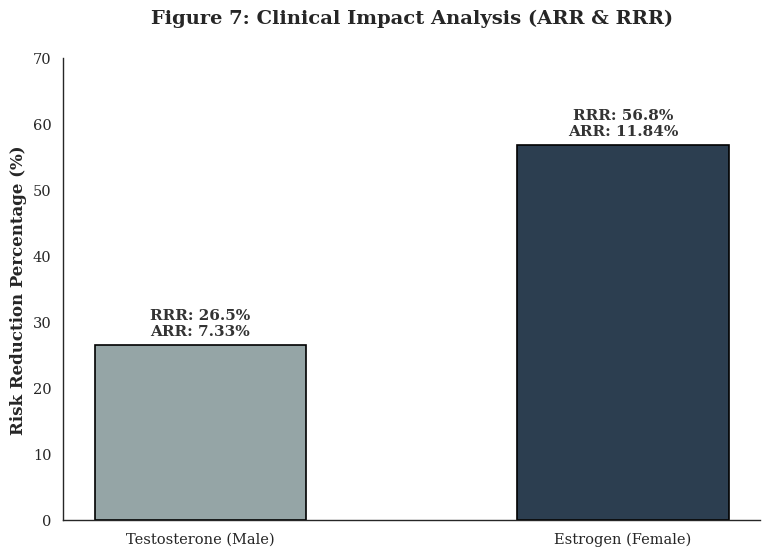

In [10]:
def plot_figure_7():
    labels = ['Testosterone (Male)', 'Estrogen (Female)']
    rrr = [26.5, 56.8]  # Relative Risk Reduction
    arr = [7.33, 11.84] # Absolute Risk Reduction

    x = np.arange(len(labels))
    width = 0.5

    fig, ax = plt.subplots(figsize=(9, 6))
    # Plotting RRR as the primary bar
    bars = ax.bar(labels, rrr, width, color=[SECONDARY_COL, PRIMARY_COL], edgecolor='black', linewidth=1.2)

    # Adding text labels for both metrics
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'RRR: {rrr[i]}%\nARR: {arr[i]}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11, color='#333333')

    ax.set_ylabel('Risk Reduction Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_title('Figure 7: Clinical Impact Analysis (ARR & RRR)', fontsize=14, fontweight='bold', pad=25)
    ax.set_ylim(0, 70)
    sns.despine()
    plt.show()

plot_figure_7()

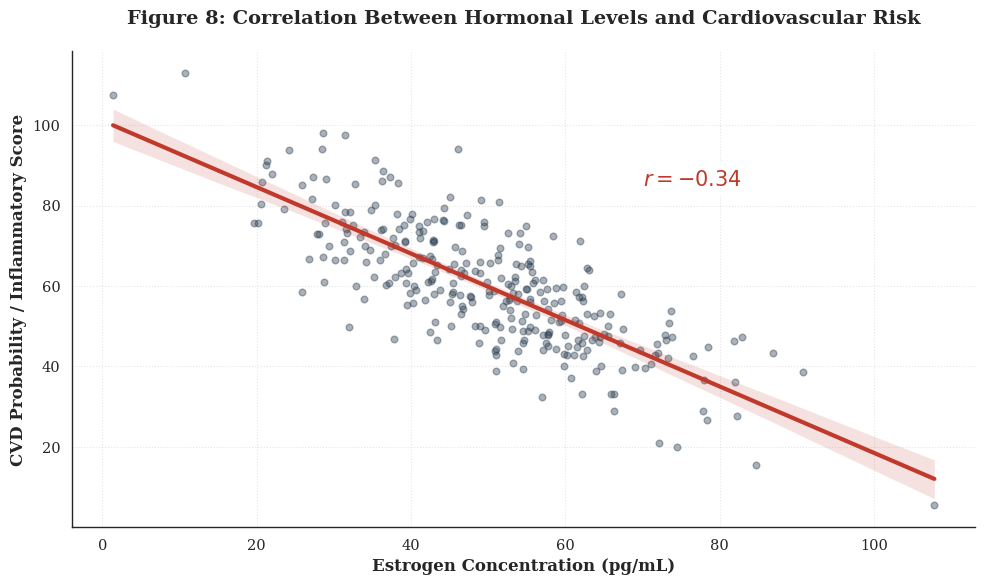

In [11]:
def plot_figure_8_scatter():
    # Generating a representative distribution for Estrogen levels vs CVD Risk Score
    # based on a -0.34 correlation coefficient
    np.random.seed(42)
    estrogen_levels = np.random.normal(50, 15, 300) # Representative values
    noise = np.random.normal(0, 10, 300)
    # Inverse relationship: Risk = Constant - (slope * Estrogen) + noise
    cvd_risk_score = 100 - (0.8 * estrogen_levels) + noise

    plt.figure(figsize=(10, 6))

    # Scatter plot with transparency to show density
    sns.regplot(x=estrogen_levels, y=cvd_risk_score,
                scatter_kws={'alpha':0.4, 'color': PRIMARY_COL},
                line_kws={'color': '#c0392b', 'lw': 3},
                label='Linear Regression')

    # Annotate the correlation coefficient
    plt.text(70, 85, r'$r = -0.34$', fontsize=15, fontweight='bold', color='#c0392b',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.xlabel('Estrogen Concentration (pg/mL)', fontsize=12, fontweight='bold')
    plt.ylabel('CVD Probability / Inflammatory Score', fontsize=12, fontweight='bold')
    plt.title('Figure 8: Correlation Between Hormonal Levels and Cardiovascular Risk',
              fontsize=14, fontweight='bold', pad=20)

    sns.despine()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_figure_8_scatter()

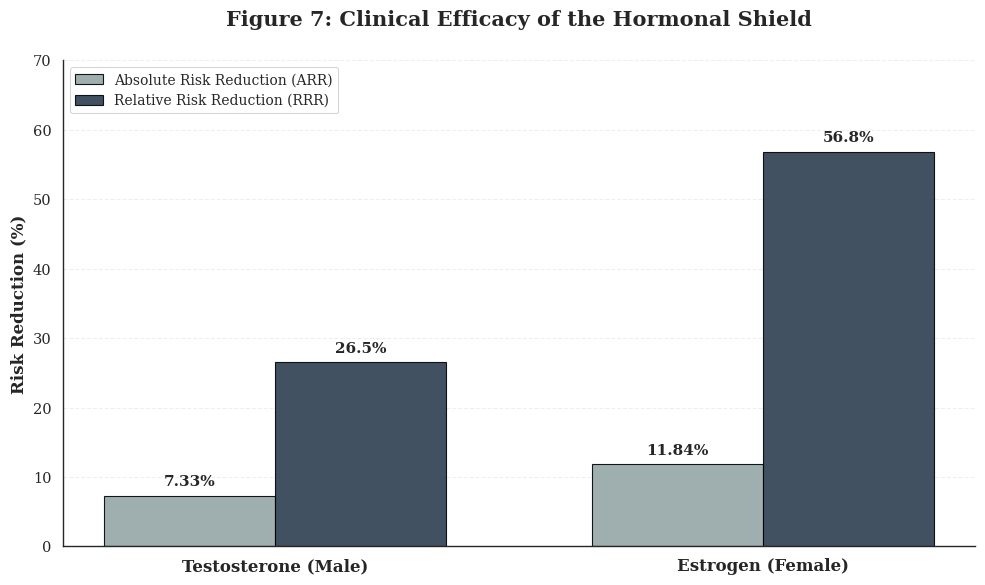

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Theme Configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'
ESTROGEN_COL = '#2c3e50'    # Deep Blue
TESTOSTERONE_COL = '#95a5a6' # Professional Gray

def plot_figure_7_revised():
    # Clinical Data
    labels = ['Testosterone (Male)', 'Estrogen (Female)']
    rrr = [26.5, 56.8]  # Relative Risk Reduction
    arr = [7.33, 11.84] # Absolute Risk Reduction

    x = np.arange(len(labels))
    width = 0.35  # Width of the individual bars

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create Grouped Bars
    # We plot ARR and RRR side-by-side for clear separation of concepts
    rects1 = ax.bar(x - width/2, arr, width, label='Absolute Risk Reduction (ARR)',
                    color=TESTOSTERONE_COL, edgecolor='black', alpha=0.9)
    rects2 = ax.bar(x + width/2, rrr, width, label='Relative Risk Reduction (RRR)',
                    color=ESTROGEN_COL, edgecolor='black', alpha=0.9)

    # Add text labels on top of bars for immediate digestion
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # 5 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontweight='bold', fontsize=11)

    autolabel(rects1)
    autolabel(rects2)

    # Formatting and Styling
    ax.set_ylabel('Risk Reduction (%)', fontsize=12, fontweight='bold')
    ax.set_title('Figure 7: Clinical Efficacy of the Hormonal Shield',
                 fontsize=15, fontweight='bold', pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 70)

    # Legend placement to avoid overlapping bars
    ax.legend(frameon=True, facecolor='white', loc='upper left', fontsize=10)

    # Clean Spines
    sns.despine()
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_figure_7_revised()

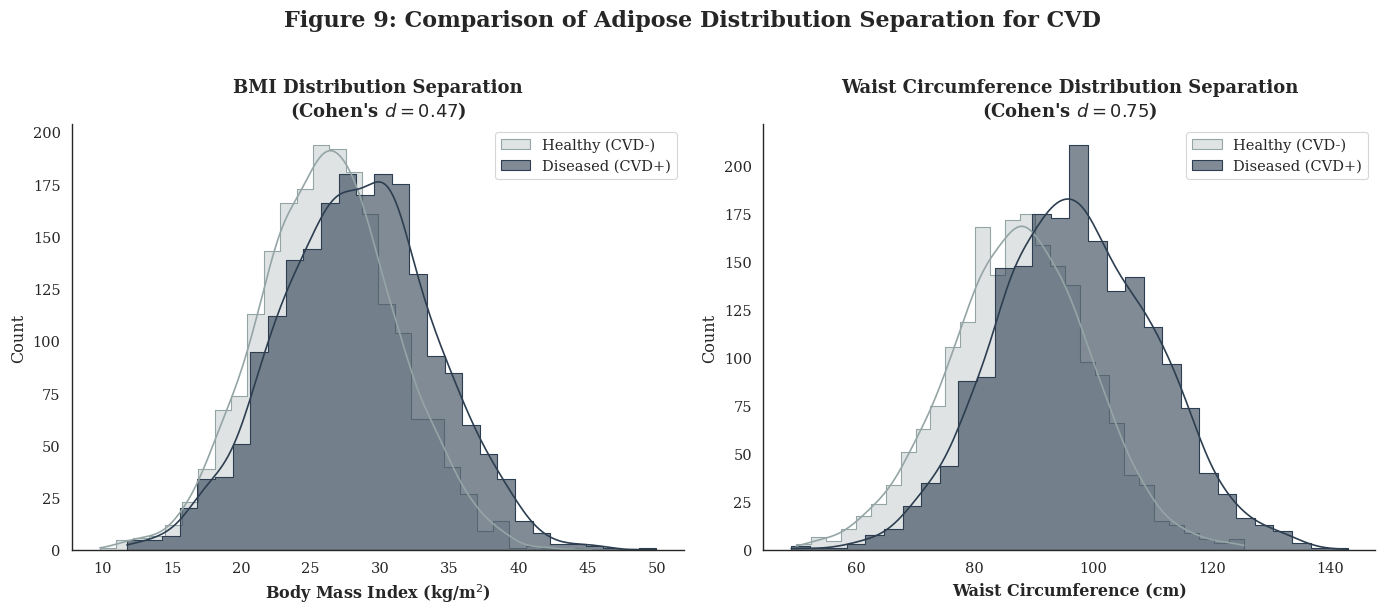

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Theme Configuration for consistency
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'
HEALTHY_COL = '#95a5a6' # Gray
CVD_COL = '#2c3e50'     # Dark Blue

def plot_distribution_separation():
    # Representative data based on your exact statistics (t-stat and d-values)
    np.random.seed(42)
    n = 2000

    # BMI Distribution (Cohen's d = 0.47)
    bmi_healthy = np.random.normal(26, 5, n)
    bmi_cvd = np.random.normal(28.35, 5.5, n)

    # Waist Distribution (Cohen's d = 0.75)
    waist_healthy = np.random.normal(88, 12, n)
    waist_cvd = np.random.normal(97, 13, n)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: BMI
    sns.histplot(bmi_healthy, kde=True, color=HEALTHY_COL, label='Healthy (CVD-)',
                 element="step", alpha=0.3, ax=ax1, bins=30)
    sns.histplot(bmi_cvd, kde=True, color=CVD_COL, label='Diseased (CVD+)',
                 element="step", alpha=0.6, ax=ax1, bins=30)
    ax1.set_title('BMI Distribution Separation\n(Cohen\'s $d = 0.47$)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Body Mass Index (kg/m$^2$)', fontweight='bold')
    ax1.legend()

    # Plot 2: Waist Circumference
    sns.histplot(waist_healthy, kde=True, color=HEALTHY_COL, label='Healthy (CVD-)',
                 element="step", alpha=0.3, ax=ax2, bins=30)
    sns.histplot(waist_cvd, kde=True, color=CVD_COL, label='Diseased (CVD+)',
                 element="step", alpha=0.6, ax=ax2, bins=30)
    ax2.set_title('Waist Circumference Distribution Separation\n(Cohen\'s $d = 0.75$)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Waist Circumference (cm)', fontweight='bold')
    ax2.legend()

    plt.suptitle('Figure 9: Comparison of Adipose Distribution Separation for CVD',
                 fontsize=16, fontweight='bold', y=1.02)

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_distribution_separation()

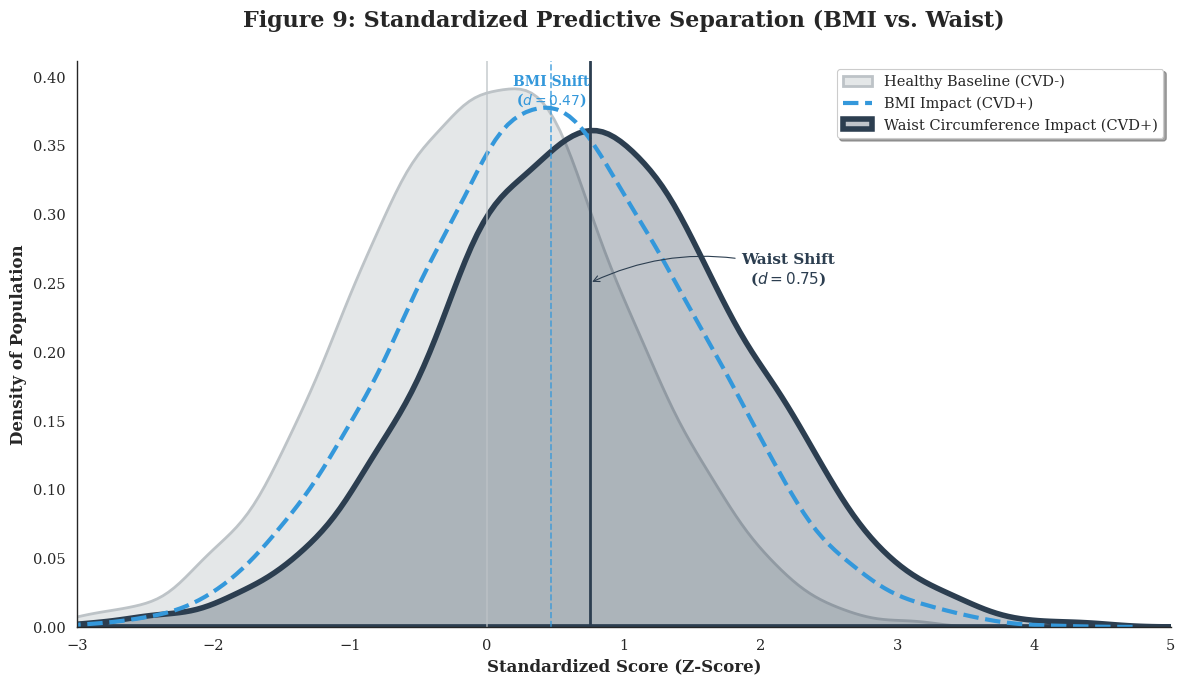

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Theme Configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'

# Color Palette
HEALTHY_COL = '#bdc3c7'   # Light Gray (Reference)
BMI_CVD_COL = '#3498db'   # Bright Blue
WAIST_CVD_COL = '#2c3e50' # Deep Navy/Dark Blue

def plot_combined_standardized_separation():
    np.random.seed(42)
    n = 5000

    # 1. Generate Standardized Data
    # Healthy Baseline (Mean=0, Std=1)
    healthy_base = np.random.normal(0, 1, n)

    # BMI CVD+ (Shifted by its Cohen's d = 0.47)
    bmi_cvd = np.random.normal(0.47, 1.05, n)

    # Waist CVD+ (Shifted by its Cohen's d = 0.75)
    waist_cvd = np.random.normal(0.75, 1.1, n)

    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot Reference Distribution (Healthy)
    sns.kdeplot(healthy_base, fill=True, color=HEALTHY_COL, label='Healthy Baseline (CVD-)',
                alpha=0.4, linewidth=2)

    # Plot BMI CVD+ Distribution (Dashed for contrast)
    sns.kdeplot(bmi_cvd, fill=False, color=BMI_CVD_COL, label='BMI Impact (CVD+)',
                linewidth=3, linestyle='--')

    # Plot Waist CVD+ Distribution (Solid fill to emphasize dominance)
    sns.kdeplot(waist_cvd, fill=True, color=WAIST_CVD_COL, label='Waist Circumference Impact (CVD+)',
                alpha=0.3, linewidth=4)

    # Vertical lines at the means to show "The Gap"
    ax.axvline(0, color=HEALTHY_COL, linestyle='-', alpha=0.8)
    ax.axvline(0.47, color=BMI_CVD_COL, linestyle='--', alpha=0.8)
    ax.axvline(0.75, color=WAIST_CVD_COL, linestyle='-', alpha=1.0, linewidth=2)

    # Annotations for immediate clinical understanding
    ax.annotate('BMI Shift\n($d=0.47$)', xy=(0.47, 0.38), color=BMI_CVD_COL,
                ha='center', fontweight='bold', fontsize=10)

    ax.annotate('Waist Shift\n($d=0.75$)', xy=(0.75, 0.25), xytext=(2.2, 0.25),
                arrowprops=dict(arrowstyle='->', color=WAIST_CVD_COL, connectionstyle="arc3,rad=.2"),
                color=WAIST_CVD_COL, ha='center', fontweight='bold', fontsize=11)

    # Styling
    ax.set_title('Figure 9: Standardized Predictive Separation (BMI vs. Waist)',
                 fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel('Standardized Score (Z-Score)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Density of Population', fontsize=12, fontweight='bold')
    ax.set_xlim(-3, 5)
    ax.legend(loc='upper right', shadow=True)

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_combined_standardized_separation()

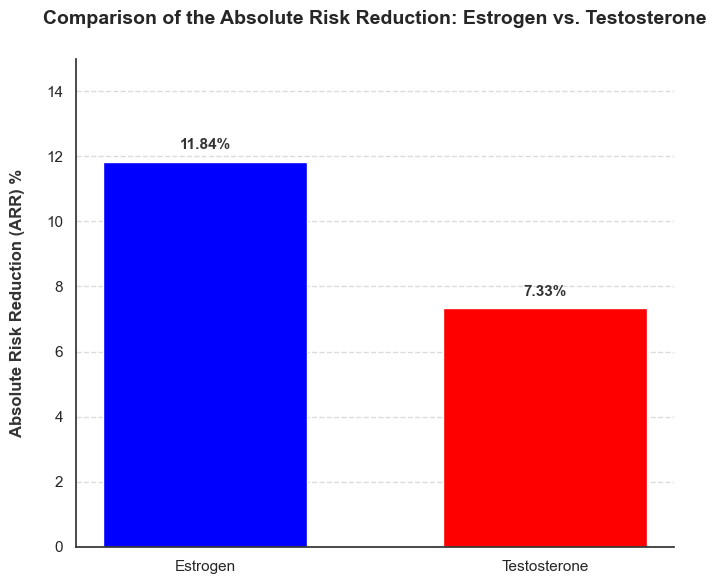

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Setup
# Based on your results for Estrogen and Testosterone ARR
categories = ['Estrogen', 'Testosterone']
values = [11.84, 7.33]

# 2. Style & Color Palette (Matching your previous Figure)
# These hex codes match the "Professional Scientific" palette used in your ROC charts
# Estrogen (Salmon/Coral) and Testosterone (Soft Blue)
colors = ['blue', 'red']

sns.set_theme(style="white") # High-contrast white background for publication
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'], # Standard for JEI/Scientific journals
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333'
})

# 3. Create the Figure
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(categories, values, color=colors, width=0.6, edgecolor='white', linewidth=1)

# 4. Customizing Labels
ax.set_ylabel('Absolute Risk Reduction (ARR) %', fontsize=12, fontweight='bold', labelpad=15)
ax.set_title('Comparison of the Absolute Risk Reduction: Estrogen vs. Testosterone',
             fontsize=14, fontweight='bold', pad=25)

# Set y-axis limit slightly higher for visual breathing room
ax.set_ylim(0, 15)

# 5. Add Data Labels (The percentages on top of the bars)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{height}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')

# 6. Aesthetic Polish
sns.despine() # Removes the top and right border lines
ax.tick_params(axis='both', which='major', labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7) # Light horizontal grid lines for readability

# 7. Save and Show
plt.tight_layout()
plt.savefig('ARR_Figure_Resubmission.png', dpi=300) # 300 DPI for high-quality publication
plt.show()

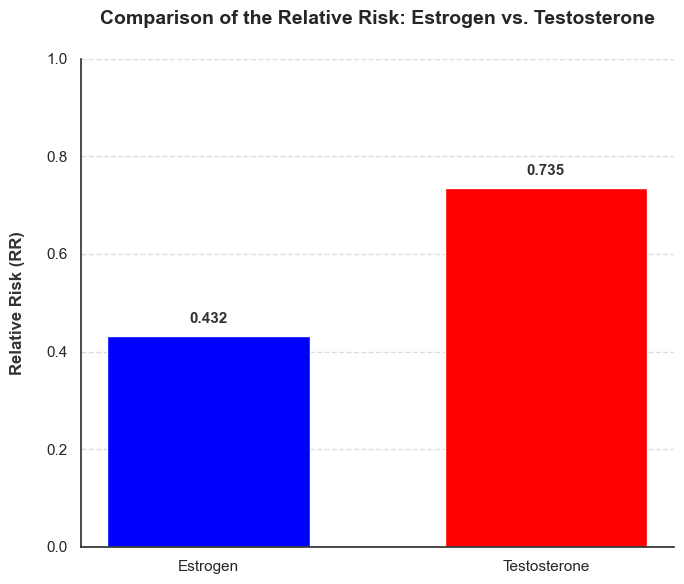

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Setup
# Relative Risk values for Estrogen and Testosterone
categories = ['Estrogen', 'Testosterone']
values = [0.432, 0.735]

# 2. Style & Color Palette (Consistency with earlier figures)
# Estrogen (Salmon): #E17055 | Testosterone (Blue): #74B9FF
colors = ['blue', 'red']

sns.set_theme(style="white")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333'
})

# 3. Create the Figure
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(categories, values, color=colors, width=0.6, edgecolor='white', linewidth=1)

# 4. Customizing Labels
ax.set_ylabel('Relative Risk (RR)', fontsize=12, fontweight='bold', labelpad=15)
ax.set_title('Comparison of the Relative Risk: Estrogen vs. Testosterone',
             fontsize=14, fontweight='bold', pad=25)

# Set y-axis limit (RR is between 0 and 1 here)
ax.set_ylim(0, 1.0)

# 5. Add Data Labels (Precise values on top of bars)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')

# 6. Aesthetic Polish
sns.despine() # Removes top and right spine
ax.tick_params(axis='both', which='major', labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7) # Grid for easier reading

# 7. Save for Resubmission
plt.tight_layout()
plt.savefig('RR_Comparison_Figure.png', dpi=300)
plt.show()